# Tutorial 4, Vapor Power Plants

In this tutorial we will be looking at an ideal Rankine plant using Cantera. This problem is identical to Problem 3 in Traditional Assignment 1. 

Problem: Water is the working fluid in an ideal Rankine cycle. Saturated vapor enters the turbine at 16 MPa, and the condenser pressure is 8 kPa. The mass flow rate of steam entering the turbine is 120 kg/s. 

![](./T4_schematic.png)

<font color='blue'>1. Determine the net power developed, in kW.</font>



In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cantera as ct

w = ct.Water()

In [42]:
# GIVENS #
m_dot = 120 # kg/s
P1 = 16e6 # Pa
P4 = 8e3 # Pa

# SOLVE FOR ALL STATES #

# State 2 #
P2 = P1
q2 = 1 # quality
w.PQ = P2, q2
s2 = w.entropy_mass
h2 = w.enthalpy_mass
T2 = w.T

# State 3 #
P3 = P4
s3 = s2 # ideal Rankine cycle
w.SP = s3, P3
h3 = w.enthalpy_mass
T3 = w.T

# State 4 #
# Ideal Rankine - assume saturated liquid at outlet of condenser
q4 = 0
w.PQ = P4, q4
h4 = w.enthalpy_mass
s4 = w.entropy_mass
T4 = w.T

# State 1 #
s1 = s4
w.SP = s1, P1
h1 = w.enthalpy_mass
T1 = w.T

# Solve for states from 1 to 2
s12 = np.linspace(s1,s2,50) # vector of entropy between s1 and s2
T12 = np.zeros(len(s12)) # initialize vector
for ii in range(len(s12)):
    w.SP = s12[ii], P1
    T12[ii] = w.T

In [43]:
# Solve question #
W_dot_T = m_dot * (h2 - h3) # Turbine work
W_dot_P = m_dot * (h1 - h4) # Pump work
W_net = W_dot_T - W_dot_P # Net work
print(f"Net work: {W_net / 1e6:.2f} MW") # MW

Net work: 111.20 MW


<font color='blue'>2. Now determine the cycle efficiency.</font>

In [44]:
# Solve question
Q_in = m_dot * (h2 - h1)
eta = W_net / Q_in
print(f"Thermal efficiency: {eta:.4f}")

Thermal efficiency: 0.3876


<font color='blue'>3. Now plot the cycle on a T-S diagram. Make a smooth line between states 1 and 2. A script to plot the vapordome is provided below.</font>

Text(4113.09651295251, 314.7042340091831, '4')

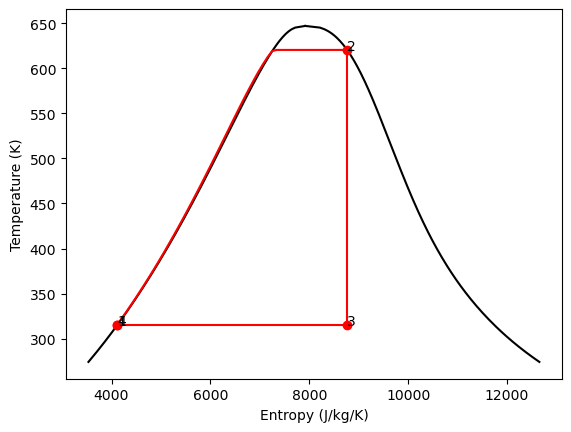

In [45]:
def plot_vapordome():
    T_vapordome = np.linspace(274,647.28,200)
    s_left = np.zeros(len(T_vapordome))
    s_right = np.zeros(len(T_vapordome))

    for ii in range(len(T_vapordome)):
        w.TQ = T_vapordome[ii], 0
        s_left[ii] = w.s
        w.TQ = T_vapordome[ii], 1
        s_right[ii] = w.s

    plt.plot(s_left,T_vapordome,'k-')
    plt.plot(s_right,T_vapordome,'k-')
    plt.xlabel('Entropy (J/kg/K)')
    plt.ylabel('Temperature (K)')

plot_vapordome()

plt.plot([s2,s3,s4,s1],[T2,T3,T4,T1],'ro-')
plt.plot(s12,T12,'r-')
plt.text(s1,T1,'1')
plt.text(s2,T2,'2')
plt.text(s3,T3,'3')
plt.text(s4,T4,'4')